# Ruitenwissermechanisme met motor in H

In deze variant zit de motor in `H` en wordt stang 7 (`theta5`) rechtstreeks aangedreven. Met realistische lengtes dicht bij het oorspronkelijke ontwerp is `theta5` geen volledige crank maar een rocker. De motor in H stuurt dus een heen-en-weergaande hoekbeweging aan.

De structuur van de oorspronkelijke notebook blijft zoveel mogelijk behouden: dezelfde namen voor de meeste grootheden, dezelfde soort sluitingsvergelijkingen, kinematica, animatie, inverse dynamica, onbalans en motoranalyse. De lengtes zijn terug dicht bij het normale ontwerp: `r2 = 0.99 m`, `r6 = 0.90 m` en `r7 = 0.50 m`.

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

plt.rcParams.update({
    'figure.figsize': (8, 4),
    'axes.grid': True,
    'grid.alpha': 0.3,
})

In [49]:
# Link lengths [m]
r1 = 0.11
r2 = 0.99
r3 = 1.53
r4 = 1.01
r5 = 1.13
r6 = 0.90
r7 = 0.50

# Distances from the quaternary link to its joints [m]
rDC = 0.16
rDF = 0.41
rED = 0.28
rIJ = 0.28

# Fixed ground points [m]
grondA_x = 0.00
grondA_y = 0.00
grondD_x = 0.76
grondD_y = 0.66
grondH_x = 1.79
grondH_y = 0.01
grondI_x = 1.77
grondI_y = 0.66

# Derived distances between ground points [m]
rAD_x = abs(grondD_x - grondA_x)
rAD_y = abs(grondD_y - grondA_y)
rDH_x = abs(grondH_x - grondD_x)
rDH_y = abs(grondH_y - grondD_y)
rDI_x = abs(grondD_x - grondI_x)
rDI_y = abs(grondD_y - grondI_y)


# Prescribed input motion: motor in H drives theta5 as a rocker.
# The range is taken from the original A-driven mechanism.
omega = 4.2
t_begin = 0
t_end = 2*np.pi/omega
Ts = 0.01
num_steps = int(np.ceil((t_end - t_begin) / Ts))
t = np.linspace(t_begin, t_end, num_steps + 1)

theta5_mid = np.deg2rad(89.4)
theta5_amp = np.deg2rad(25.0)
theta5 = theta5_mid + theta5_amp*np.cos(omega*t)
dtheta5 = -theta5_amp*omega*np.sin(omega*t)
ddtheta5 = -theta5_amp*omega**2*np.cos(omega*t)

# Unknown angles solved from closure. These are only initial guesses.
theta1_init = np.deg2rad(209)
theta2_init = np.deg2rad(34)
theta3_init = np.deg2rad(76)
theta4_init = np.deg2rad(12)
theta6_init = np.deg2rad(0)
theta7_init = np.deg2rad(76)

# Arrays for the non-driven links.
theta1 = np.zeros_like(t)
theta2 = np.zeros_like(t)
theta3 = np.zeros_like(t)
theta4 = np.zeros_like(t)
theta6 = np.zeros_like(t)
theta7 = np.zeros_like(t)
dtheta1 = np.zeros_like(t)
dtheta2 = np.zeros_like(t)
dtheta3 = np.zeros_like(t)
dtheta4 = np.zeros_like(t)
dtheta6 = np.zeros_like(t)
dtheta7 = np.zeros_like(t)
ddtheta1 = np.zeros_like(t)
ddtheta2 = np.zeros_like(t)
ddtheta3 = np.zeros_like(t)
ddtheta4 = np.zeros_like(t)
ddtheta6 = np.zeros_like(t)
ddtheta7 = np.zeros_like(t)

In [50]:
def rotate_vector(z, theta):
    rotation_matrix = np.array([[np.cos(theta), -np.sin(theta)],
                                [np.sin(theta),  np.cos(theta)]])
    return np.dot(rotation_matrix, z)

# Same function structure as before, but the prescribed angle is now theta5_driver.
# Unknowns are theta1, theta2, theta3, theta4, theta6 and theta7.
def loop_closure_eqs(theta_init, theta5_driver, r1, r2, r3, r4, r5, r6, r7, rDC, rDF, rED, rIJ, rAD_x, rAD_y, rDI_x, rDI_y):
    theta1_u = theta_init[0]
    theta2_u = theta_init[1]
    theta3_u = theta_init[2]
    theta4_u = theta_init[3]
    theta6_u = theta_init[4]
    theta7_u = theta_init[5]

    F1 = r1*np.cos(theta1_u) + r2*np.cos(theta2_u) + rDC*np.cos(theta3_u) - rAD_x
    F2 = r1*np.sin(theta1_u) + r2*np.sin(theta2_u) + rDC*np.sin(theta3_u) - rAD_y

    F3 = -rDF*np.cos(theta3_u) + r6*np.cos(theta4_u) - r7*np.cos(theta5_driver) - rDH_x
    F4 = -rDF*np.sin(theta3_u) + r6*np.sin(theta4_u) - r7*np.sin(theta5_driver) + rDH_y

    F5 = rED*np.cos(theta3_u) + r4*np.cos(theta6_u) - rIJ*np.cos(theta7_u) - rDI_x
    F6 = rED*np.sin(theta3_u) + r4*np.sin(theta6_u) - rIJ*np.sin(theta7_u) - rDI_y

    return [F1, F2, F3, F4, F5, F6]

In [51]:
def angles_at_time_zero(r1, r2, r3, r4, r5, r6, r7, rDC, rDF, rED, rIJ, rAD_x, rAD_y, rDI_x, rDI_y, theta5, dtheta5, ddtheta5, theta1_init, theta2_init, theta3_init, theta4_init, theta6_init, theta7_init, t):
    optim_options = {"full_output": True}
    k = 0
    x, _, ier, message = fsolve(
        lambda x: loop_closure_eqs(x, theta5[k], r1, r2, r3, r4, r5, r6, r7, rDC, rDF, rED, rIJ, rAD_x, rAD_y, rDI_x, rDI_y),
        [theta1_init, theta2_init, theta3_init, theta4_init, theta6_init, theta7_init],
        **optim_options
    )
    if ier != 1:
        print('The fsolve exit flag was not 1, probably no convergence!')
        print(message)
    return x

theta1_0, theta2_0, theta3_0, theta4_0, theta6_0, theta7_0 = angles_at_time_zero(
    r1, r2, r3, r4, r5, r6, r7, rDC, rDF, rED, rIJ,
    rAD_x, rAD_y, rDI_x, rDI_y, theta5, dtheta5, ddtheta5,
    theta1_init, theta2_init, theta3_init, theta4_init, theta6_init, theta7_init, t
)
print('Beginstand met motor in H')
print(f'theta5 motor = {np.rad2deg(theta5[0]):.2f} deg')
print(f'theta1 = {np.rad2deg(theta1_0):.2f} deg')
print(f'theta2 = {np.rad2deg(theta2_0):.2f} deg')
print(f'theta3 = {np.rad2deg(theta3_0):.2f} deg')
print(f'theta4 = {np.rad2deg(theta4_0):.2f} deg')
print(f'theta6 = {np.rad2deg(theta6_0):.2f} deg')
print(f'theta7 = {np.rad2deg(theta7_0):.2f} deg')

Beginstand met motor in H
theta5 motor = 114.40 deg
theta1 = 183.43 deg
theta2 = 30.86 deg
theta3 = 82.83 deg
theta4 = 13.63 deg
theta6 = -0.00 deg
theta7 = 82.83 deg


In [52]:
def kinematics(r1, r2, r3, r4, r5, r6, r7, rDC, rDF, rED, rIJ, rAD_x, rAD_y, rDI_x, rDI_y, theta5, dtheta5, ddtheta5, theta1_init, theta2_init, theta3_init, theta4_init, theta6_init, theta7_init, t):
    optim_options = {"full_output": True}
    theta1 = np.zeros_like(t); theta2 = np.zeros_like(t); theta3 = np.zeros_like(t)
    theta4 = np.zeros_like(t); theta6 = np.zeros_like(t); theta7 = np.zeros_like(t)
    dtheta1 = np.zeros_like(t); dtheta2 = np.zeros_like(t); dtheta3 = np.zeros_like(t)
    dtheta4 = np.zeros_like(t); dtheta6 = np.zeros_like(t); dtheta7 = np.zeros_like(t)
    ddtheta1 = np.zeros_like(t); ddtheta2 = np.zeros_like(t); ddtheta3 = np.zeros_like(t)
    ddtheta4 = np.zeros_like(t); ddtheta6 = np.zeros_like(t); ddtheta7 = np.zeros_like(t)
    cond = np.zeros_like(t)
    failures = 0

    for k, time in enumerate(t):
        x, _, ier, message = fsolve(
            lambda x: loop_closure_eqs(x, theta5[k], r1, r2, r3, r4, r5, r6, r7, rDC, rDF, rED, rIJ, rAD_x, rAD_y, rDI_x, rDI_y),
            [theta1_init, theta2_init, theta3_init, theta4_init, theta6_init, theta7_init],
            **optim_options
        )
        if ier != 1:
            failures += 1

        theta1[k], theta2[k], theta3[k], theta4[k], theta6[k], theta7[k] = x

        A = np.array([
            [-r1*np.sin(theta1[k]), -r2*np.sin(theta2[k]), -rDC*np.sin(theta3[k]), 0, 0, 0],
            [ r1*np.cos(theta1[k]),  r2*np.cos(theta2[k]),  rDC*np.cos(theta3[k]), 0, 0, 0],
            [0, 0,  rDF*np.sin(theta3[k]), -r6*np.sin(theta4[k]), 0, 0],
            [0, 0, -rDF*np.cos(theta3[k]),  r6*np.cos(theta4[k]), 0, 0],
            [0, 0, -rED*np.sin(theta3[k]), 0, -r4*np.sin(theta6[k]),  rIJ*np.sin(theta7[k])],
            [0, 0,  rED*np.cos(theta3[k]), 0,  r4*np.cos(theta6[k]), -rIJ*np.cos(theta7[k])]
        ])
        B = np.array([0, 0, -r7*np.sin(theta5[k])*dtheta5[k], r7*np.cos(theta5[k])*dtheta5[k], 0, 0])
        x_vel = np.linalg.solve(A, B)
        cond[k] = np.linalg.cond(A)
        dtheta1[k], dtheta2[k], dtheta3[k], dtheta4[k], dtheta6[k], dtheta7[k] = x_vel

        B = np.array([
            r1*np.cos(theta1[k])*dtheta1[k]**2 + r2*np.cos(theta2[k])*dtheta2[k]**2 + rDC*np.cos(theta3[k])*dtheta3[k]**2,
            r1*np.sin(theta1[k])*dtheta1[k]**2 + r2*np.sin(theta2[k])*dtheta2[k]**2 + rDC*np.sin(theta3[k])*dtheta3[k]**2,
            -rDF*np.cos(theta3[k])*dtheta3[k]**2 + r6*np.cos(theta4[k])*dtheta4[k]**2 - r7*np.cos(theta5[k])*dtheta5[k]**2 - r7*np.sin(theta5[k])*ddtheta5[k],
            -rDF*np.sin(theta3[k])*dtheta3[k]**2 + r6*np.sin(theta4[k])*dtheta4[k]**2 - r7*np.sin(theta5[k])*dtheta5[k]**2 + r7*np.cos(theta5[k])*ddtheta5[k],
            rED*np.cos(theta3[k])*dtheta3[k]**2 + r4*np.cos(theta6[k])*dtheta6[k]**2 - rIJ*np.cos(theta7[k])*dtheta7[k]**2,
            rED*np.sin(theta3[k])*dtheta3[k]**2 + r4*np.sin(theta6[k])*dtheta6[k]**2 - rIJ*np.sin(theta7[k])*dtheta7[k]**2,
        ])
        x_acc = np.linalg.solve(A, B)
        ddtheta1[k], ddtheta2[k], ddtheta3[k], ddtheta4[k], ddtheta6[k], ddtheta7[k] = x_acc

        theta1_init = theta1[k] + (t[1]-t[0])*dtheta1[k]
        theta2_init = theta2[k] + (t[1]-t[0])*dtheta2[k]
        theta3_init = theta3[k] + (t[1]-t[0])*dtheta3[k]
        theta4_init = theta4[k] + (t[1]-t[0])*dtheta4[k]
        theta6_init = theta6[k] + (t[1]-t[0])*dtheta6[k]
        theta7_init = theta7[k] + (t[1]-t[0])*dtheta7[k]

    if failures:
        print(f'Waarschuwing: fsolve convergeerde niet op {failures} tijdstappen.')
    return theta1, theta2, theta3, theta4, theta6, theta7, dtheta1, dtheta2, dtheta3, dtheta4, dtheta6, dtheta7, ddtheta1, ddtheta2, ddtheta3, ddtheta4, ddtheta6, ddtheta7, cond

theta1, theta2, theta3, theta4, theta6, theta7, dtheta1, dtheta2, dtheta3, dtheta4, dtheta6, dtheta7, ddtheta1, ddtheta2, ddtheta3, ddtheta4, ddtheta6, ddtheta7, cond = kinematics(
    r1, r2, r3, r4, r5, r6, r7, rDC, rDF, rED, rIJ, rAD_x, rAD_y, rDI_x, rDI_y,
    theta5, dtheta5, ddtheta5, theta1_init, theta2_init, theta3_init, theta4_init, theta6_init, theta7_init, t
)
print(f'Maximum condition number: {np.max(cond):.3g}')
print(f'Motor theta5 range: {np.rad2deg(np.min(theta5)):.1f} deg to {np.rad2deg(np.max(theta5)):.1f} deg')

Maximum condition number: 21.2
Motor theta5 range: 64.4 deg to 114.4 deg


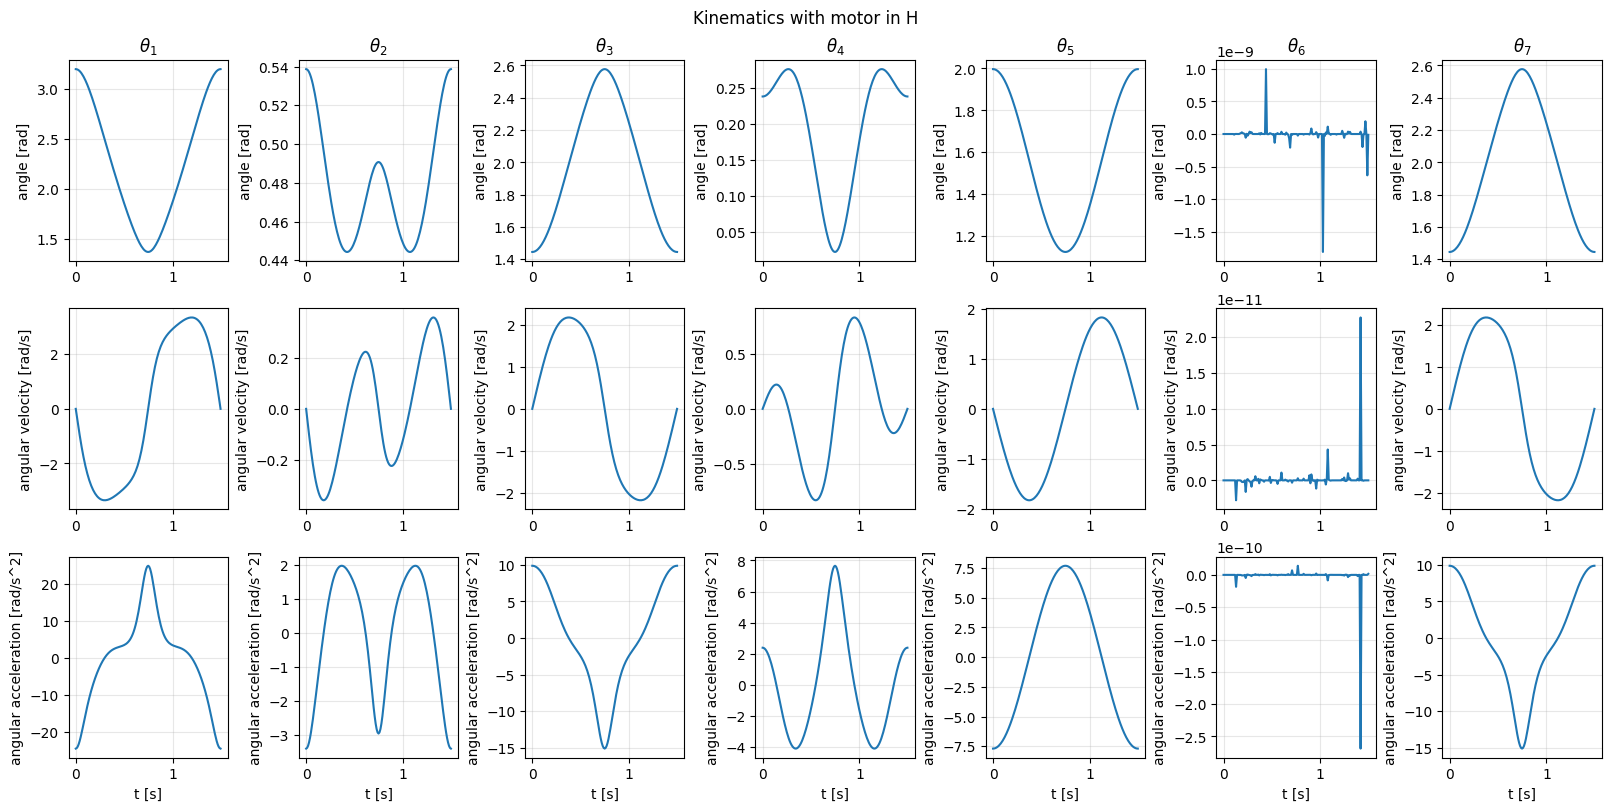

In [53]:
# plot position, velocity and acceleration profiles:
fig1, ax1 = plt.subplots(nrows=3, ncols=7, constrained_layout=True, figsize=(16, 8))
fig1.suptitle('Kinematics with motor in H')

angles = [theta1, theta2, theta3, theta4, theta5, theta6, theta7]
velocities = [dtheta1, dtheta2, dtheta3, dtheta4, dtheta5, dtheta6, dtheta7]
accelerations = [ddtheta1, ddtheta2, ddtheta3, ddtheta4, ddtheta5, ddtheta6, ddtheta7]
names = [r'$\theta_1$', r'$\theta_2$', r'$\theta_3$', r'$\theta_4$', r'$\theta_5$', r'$\theta_6$', r'$\theta_7$']

for j, name in enumerate(names):
    ax1[0, j].plot(t, angles[j])
    ax1[0, j].set_title(name)
    ax1[0, j].set_ylabel('angle [rad]')
    ax1[1, j].plot(t, velocities[j])
    ax1[1, j].set_ylabel('angular velocity [rad/s]')
    ax1[2, j].plot(t, accelerations[j])
    ax1[2, j].set_ylabel('angular acceleration [rad/s^2]')
    ax1[2, j].set_xlabel('t [s]')
plt.show()

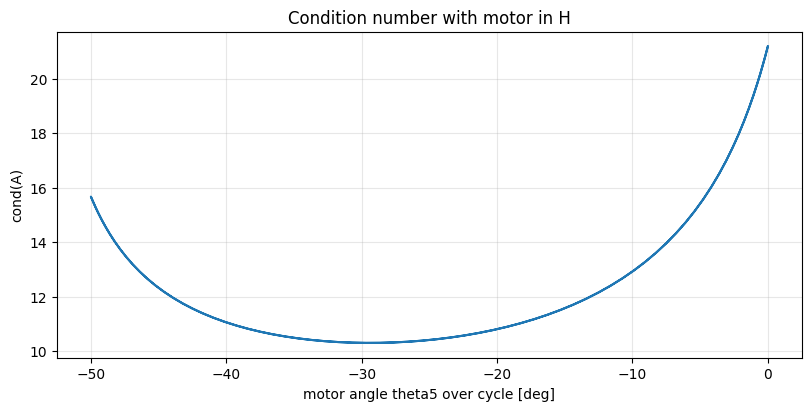

In [54]:
# plot of condition number:
theta5_cycle_deg = np.rad2deg(theta5 - theta5[0])
fig_cond, ax_cond = plt.subplots(constrained_layout=True, figsize=(8, 4))
ax_cond.plot(theta5_cycle_deg, cond)
ax_cond.set_title('Condition number with motor in H')
ax_cond.set_xlabel('motor angle theta5 over cycle [deg]')
ax_cond.set_ylabel('cond(A)')
ax_cond.grid(True)
plt.show()

In [55]:
# Animation of mechanism motion
from matplotlib import animation
from IPython.display import HTML

A0 = np.array([grondA_x, grondA_y])
D0 = np.array([grondD_x, grondD_y])
H0 = np.array([grondH_x, grondH_y])
I0 = np.array([grondI_x, grondI_y])

fig_anim, ax_anim = plt.subplots(figsize=(7, 5))
ax_anim.set_aspect('equal', adjustable='box')
x_left = min(grondA_x-r1-0.4, grondD_x - rDF - 0.1, grondI_x - 0.1, grondH_x - r7 - 0.1)
x_right = max(grondH_x + r7 + 0.1, grondI_x + r5 + 0.1, grondD_x + r3 + 0.1)
y_bottom = min(grondA_y - r1 - 0.1, grondH_y - r7 - 0.1)
y_top = max(grondD_y + r3 + 0.1, grondI_y + r5 + 0.1)
ax_anim.set_xlim(x_left, x_right)
ax_anim.set_ylim(y_bottom, y_top)
ax_anim.grid(True)
ax_anim.set_title('Mechanism animation - motor in H')

line_AB, = ax_anim.plot([], [], 'o-', label='1: A-B')
line_BC, = ax_anim.plot([], [], 'o-', label='2: B-C')
line_CDEF, = ax_anim.plot([], [], 'o-', label='3: C-D-E-F')
line_EK, = ax_anim.plot([], [], 'o-', linewidth=2, label='wisser links')
line_EJ, = ax_anim.plot([], [], 'o-', label='4: E-J')
line_IJ, = ax_anim.plot([], [], 'o-', label='5: I-J')
line_JL, = ax_anim.plot([], [], 'o-', linewidth=2, label='wisser rechts')
line_FG, = ax_anim.plot([], [], 'o-', label='6: F-G')
line_HG, = ax_anim.plot([], [], 'o-', label='7: H-G motor')
ax_anim.legend(loc='upper right', fontsize=8)

frames = min(len(t), 120)
index_vec = np.linspace(0, len(t)-1, frames, dtype=int)

def update(frame):
    k = index_vec[frame]
    A = A0
    D = D0
    H = H0
    I = I0
    B = A + rotate_vector(np.array([r1, 0]), theta1[k])
    C = D - rotate_vector(np.array([rDC, 0]), theta3[k])
    E = D + rotate_vector(np.array([rED, 0]), theta3[k])
    F = D - rotate_vector(np.array([rDF, 0]), theta3[k])
    G = H + rotate_vector(np.array([r7, 0]), theta5[k])
    J = I + rotate_vector(np.array([rIJ, 0]), theta7[k])
    K = F + rotate_vector(np.array([r3, 0]), theta3[k])
    L = I + rotate_vector(np.array([r5, 0]), theta7[k])

    line_AB.set_data([A[0], B[0]], [A[1], B[1]])
    line_BC.set_data([B[0], C[0]], [B[1], C[1]])
    line_CDEF.set_data([C[0], D[0], E[0], F[0]], [C[1], D[1], E[1], F[1]])
    line_EK.set_data([E[0], K[0]], [E[1], K[1]])
    line_EJ.set_data([E[0], J[0]], [E[1], J[1]])
    line_IJ.set_data([I[0], J[0]], [I[1], J[1]])
    line_JL.set_data([J[0], L[0]], [J[1], L[1]])
    line_FG.set_data([F[0], G[0]], [F[1], G[1]])
    line_HG.set_data([H[0], G[0]], [H[1], G[1]])
    return line_AB, line_BC, line_CDEF, line_EK, line_EJ, line_IJ, line_JL, line_FG, line_HG

ani = animation.FuncAnimation(fig_anim, update, frames=frames, interval=40, blit=True)
plt.close(fig_anim)
HTML(ani.to_jshtml())

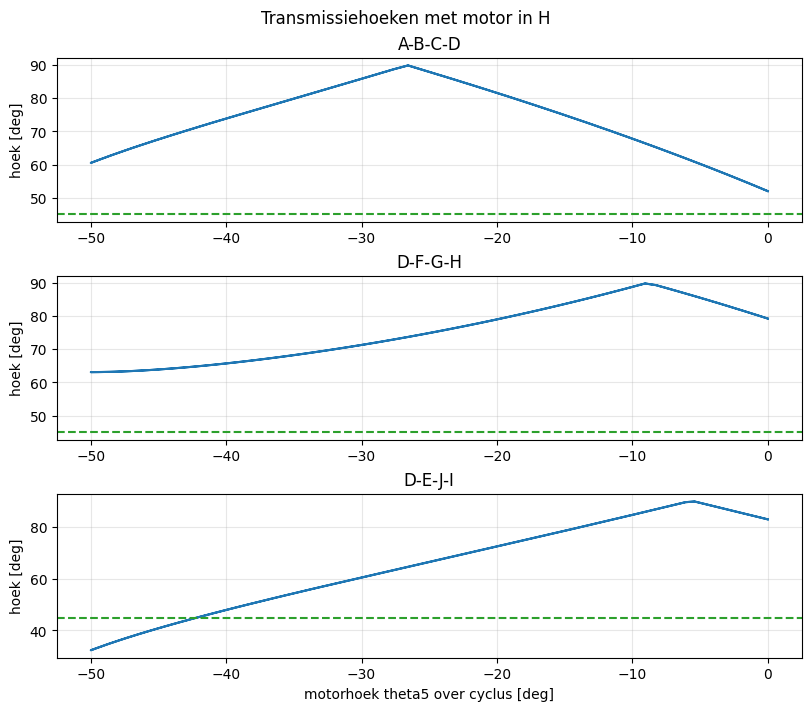

Minimum effective transmission angles
A-B-C-D: 51.97 deg
D-F-G-H: 63.10 deg
D-E-J-I: 32.37 deg


In [56]:
def effective_transmission_angle(theta_a, theta_b):
    gamma = np.abs(theta_a - theta_b)
    gamma = np.mod(gamma, 2*np.pi)
    gamma = np.minimum(gamma, 2*np.pi - gamma)
    return np.minimum(gamma, np.pi - gamma)

gamma_BCD = effective_transmission_angle(theta2, theta3)
gamma_FGH = effective_transmission_angle(theta4, theta5)
gamma_EJI = effective_transmission_angle(theta6, theta7)
theta5_cycle_deg = np.rad2deg(theta5 - theta5[0])

fig_trans, ax_trans = plt.subplots(nrows=3, ncols=1, constrained_layout=True, figsize=(8, 7))
fig_trans.suptitle('Transmissiehoeken met motor in H')
for axis, gamma, title in zip(ax_trans, [gamma_BCD, gamma_FGH, gamma_EJI], ['A-B-C-D', 'D-F-G-H', 'D-E-J-I']):
    axis.plot(theta5_cycle_deg, np.rad2deg(gamma))
    axis.axhline(45, color='tab:green', linestyle='--')
    axis.set_title(title)
    axis.set_ylabel('hoek [deg]')
ax_trans[-1].set_xlabel('motorhoek theta5 over cyclus [deg]')
plt.show()

print('Minimum effective transmission angles')
print(f'A-B-C-D: {np.rad2deg(np.min(gamma_BCD)):.2f} deg')
print(f'D-F-G-H: {np.rad2deg(np.min(gamma_FGH)):.2f} deg')
print(f'D-E-J-I: {np.rad2deg(np.min(gamma_EJI)):.2f} deg')

In [57]:
# dynamic parameters
X1 = r1/2; X2 = r2/2; X3 = r3/2 - rDF; X4 = r4/2; X5 = r5/2; X6 = r6/2; X7 = r7/2
Y1 = Y2 = Y3 = Y4 = Y5 = Y6 = Y7 = 0.0

diameter = 0.01
mass_per_length = 7850*np.pi*(diameter/2)**2
m1 = r1*mass_per_length; m2 = r2*mass_per_length; m3 = r3*mass_per_length
m4 = r4*mass_per_length; m5 = r5*mass_per_length; m6 = r6*mass_per_length; m7 = r7*mass_per_length
m_total = m1+m2+m3+m4+m5+m6+m7
g = 9.81
cycle_time = t[-1]-t[0]
def cycle_average(signal): return np.trapezoid(signal, t)/cycle_time
J1 = m1*r1**2/12; J2 = m2*r2**2/12; J3 = m3*r3**2/12; J4 = m4*r4**2/12; J5 = m5*r5**2/12; J6 = m6*r6**2/12; J7 = m7*r7**2/12
print(f'Total moving mass: {m_total:.3f} kg')

Total moving mass: 3.804 kg


In [58]:
def point_kinematics(point_x, point_y, angle, dangle, ddangle):
    vx = -point_x*np.sin(angle)*dangle - point_y*np.sin(angle + np.pi/2)*dangle
    vy =  point_x*np.cos(angle)*dangle + point_y*np.cos(angle + np.pi/2)*dangle
    ax = -point_x*(np.cos(angle)*dangle**2 + np.sin(angle)*ddangle) - point_y*(np.cos(angle + np.pi/2)*dangle**2 + np.sin(angle + np.pi/2)*ddangle)
    ay = -point_x*(np.sin(angle)*dangle**2 - np.cos(angle)*ddangle) - point_y*(np.sin(angle + np.pi/2)*dangle**2 - np.cos(angle + np.pi/2)*ddangle)
    return vx, vy, ax, ay

# Compute CG absolute positions first.
B_x = grondA_x + r1*np.cos(theta1); B_y = grondA_y + r1*np.sin(theta1)
D_x = grondD_x; D_y = grondD_y
E_x = D_x + rED*np.cos(theta3); E_y = D_y + rED*np.sin(theta3)
F_x = D_x - rDF*np.cos(theta3); F_y = D_y - rDF*np.sin(theta3)
H_x = grondH_x; H_y = grondH_y
I_x = grondI_x; I_y = grondI_y

cog_1_x = grondA_x + X1*np.cos(theta1); cog_1_y = grondA_y + X1*np.sin(theta1)
cog_2_x = B_x + X2*np.cos(theta2); cog_2_y = B_y + X2*np.sin(theta2)
cog_3_x = D_x + X3*np.cos(theta3); cog_3_y = D_y + X3*np.sin(theta3)
cog_4_x = E_x + X4*np.cos(theta6); cog_4_y = E_y + X4*np.sin(theta6)
cog_5_x = I_x + X5*np.cos(theta7); cog_5_y = I_y + X5*np.sin(theta7)
cog_6_x = F_x + X6*np.cos(theta4); cog_6_y = F_y + X6*np.sin(theta4)
cog_7_x = H_x + X7*np.cos(theta5); cog_7_y = H_y + X7*np.sin(theta5)

# Use the original rigid-body relative formulas through numerical gradients for compactness.
def grad(signal): return np.gradient(signal, t)
vel_1x, vel_1y = grad(cog_1_x), grad(cog_1_y); acc_1x, acc_1y = grad(vel_1x), grad(vel_1y)
vel_2x, vel_2y = grad(cog_2_x), grad(cog_2_y); acc_2x, acc_2y = grad(vel_2x), grad(vel_2y)
vel_3x, vel_3y = grad(cog_3_x), grad(cog_3_y); acc_3x, acc_3y = grad(vel_3x), grad(vel_3y)
vel_4x, vel_4y = grad(cog_4_x), grad(cog_4_y); acc_4x, acc_4y = grad(vel_4x), grad(vel_4y)
vel_5x, vel_5y = grad(cog_5_x), grad(cog_5_y); acc_5x, acc_5y = grad(vel_5x), grad(vel_5y)
vel_6x, vel_6y = grad(cog_6_x), grad(cog_6_y); acc_6x, acc_6y = grad(vel_6x), grad(vel_6y)
vel_7x, vel_7y = grad(cog_7_x), grad(cog_7_y); acc_7x, acc_7y = grad(vel_7x), grad(vel_7y)

# Wiper friction, same structure as original.
mu_wiper_glass = 0.60
normal_force_wiper = 3.0
v_regularisation = 1e-4
s_wiper_left = 0.5*(r3-rDF)
s_wiper_right = 0.5*r5
vel_wiper_left_x = -s_wiper_left*np.sin(theta3)*dtheta3
vel_wiper_left_y =  s_wiper_left*np.cos(theta3)*dtheta3
vel_wiper_right_x = -s_wiper_right*np.sin(theta7)*dtheta7
vel_wiper_right_y =  s_wiper_right*np.cos(theta7)*dtheta7
speed_wiper_left = np.hypot(vel_wiper_left_x, vel_wiper_left_y)
speed_wiper_right = np.hypot(vel_wiper_right_x, vel_wiper_right_y)
F_wiper_left_x = -mu_wiper_glass*normal_force_wiper*vel_wiper_left_x/(speed_wiper_left+v_regularisation)
F_wiper_left_y = -mu_wiper_glass*normal_force_wiper*vel_wiper_left_y/(speed_wiper_left+v_regularisation)
F_wiper_right_x = -mu_wiper_glass*normal_force_wiper*vel_wiper_right_x/(speed_wiper_right+v_regularisation)
F_wiper_right_y = -mu_wiper_glass*normal_force_wiper*vel_wiper_right_y/(speed_wiper_right+v_regularisation)
M_wiper_left_cog = ((s_wiper_left-X3)*np.cos(theta3))*F_wiper_left_y - ((s_wiper_left-X3)*np.sin(theta3))*F_wiper_left_x
M_wiper_right_cog = ((s_wiper_right-X5)*np.cos(theta7))*F_wiper_right_y - ((s_wiper_right-X5)*np.sin(theta7))*F_wiper_right_x

c_hinge = 0.010; M_c_hinge = 0.015; omega_regularisation = 1e-3
def hinge_friction_torque(omega_rel): return -c_hinge*omega_rel - M_c_hinge*np.tanh(omega_rel/omega_regularisation)
M_hinge_1 = hinge_friction_torque(dtheta1); M_hinge_2 = np.zeros_like(t); M_hinge_3 = hinge_friction_torque(dtheta3)
M_hinge_4 = np.zeros_like(t); M_hinge_5 = hinge_friction_torque(dtheta7); M_hinge_6 = np.zeros_like(t); M_hinge_7 = hinge_friction_torque(dtheta5)
def add_internal_hinge_friction(M_i, M_j, omega_i, omega_j):
    torque_on_j = hinge_friction_torque(omega_j - omega_i)
    return M_i - torque_on_j, M_j + torque_on_j
M_hinge_1, M_hinge_2 = add_internal_hinge_friction(M_hinge_1, M_hinge_2, dtheta1, dtheta2)
M_hinge_2, M_hinge_3 = add_internal_hinge_friction(M_hinge_2, M_hinge_3, dtheta2, dtheta3)
M_hinge_3, M_hinge_4 = add_internal_hinge_friction(M_hinge_3, M_hinge_4, dtheta3, dtheta6)
M_hinge_3, M_hinge_6 = add_internal_hinge_friction(M_hinge_3, M_hinge_6, dtheta3, dtheta4)
M_hinge_6, M_hinge_7 = add_internal_hinge_friction(M_hinge_6, M_hinge_7, dtheta4, dtheta5)
M_hinge_4, M_hinge_5 = add_internal_hinge_friction(M_hinge_4, M_hinge_5, dtheta6, dtheta7)

In [59]:
def dynamics_ruitenwissers(theta1, theta2, theta3, theta4, theta5, theta6, theta7,
                           dtheta1, dtheta2, dtheta3, dtheta4, dtheta5, dtheta6, dtheta7,
                           ddtheta1, ddtheta2, ddtheta3, ddtheta4, ddtheta5, ddtheta6, ddtheta7,
                           r1, r2, r3, r4, r5, r6, r7, rDC, rDF, rED, rIJ,
                           m1, m2, m3, m4, m5, m6, m7, g,
                           X1, X2, X3, X4, X5, X6, X7,
                           Y1, Y2, Y3, Y4, Y5, Y6, Y7,
                           J1, J2, J3, J4, J5, J6, J7,
                           acc_1x, acc_1y, acc_2x, acc_2y, acc_3x, acc_3y, acc_4x, acc_4y,
                           acc_5x, acc_5y, acc_6x, acc_6y, acc_7x, acc_7y,
                           F_wiper_left_x, F_wiper_left_y, F_wiper_right_x, F_wiper_right_y,
                           M_wiper_left_cog, M_wiper_right_cog,
                           M_hinge_1, M_hinge_2, M_hinge_3, M_hinge_4,
                           M_hinge_5, M_hinge_6, M_hinge_7, t):
    # Build relative vectors from CGs to joints.
    cog1_A_x = grondA_x - cog_1_x; cog1_A_y = grondA_y - cog_1_y
    cog1_B_x = B_x - cog_1_x;      cog1_B_y = B_y - cog_1_y
    cog2_B_x = B_x - cog_2_x;      cog2_B_y = B_y - cog_2_y
    C_x = grondD_x - rDC*np.cos(theta3); C_y = grondD_y - rDC*np.sin(theta3)
    cog2_C_x = C_x - cog_2_x;      cog2_C_y = C_y - cog_2_y
    cog3_C_x = C_x - cog_3_x;      cog3_C_y = C_y - cog_3_y
    cog3_D_x = grondD_x - cog_3_x; cog3_D_y = grondD_y - cog_3_y
    cog3_E_x = E_x - cog_3_x;      cog3_E_y = E_y - cog_3_y
    cog3_F_x = F_x - cog_3_x;      cog3_F_y = F_y - cog_3_y
    J_x = grondI_x + rIJ*np.cos(theta7); J_y = grondI_y + rIJ*np.sin(theta7)
    G_x = grondH_x + r7*np.cos(theta5);  G_y = grondH_y + r7*np.sin(theta5)
    cog4_E_x = E_x - cog_4_x;      cog4_E_y = E_y - cog_4_y
    cog4_J_x = J_x - cog_4_x;      cog4_J_y = J_y - cog_4_y
    cog5_I_x = grondI_x - cog_5_x; cog5_I_y = grondI_y - cog_5_y
    cog5_J_x = J_x - cog_5_x;      cog5_J_y = J_y - cog_5_y
    cog6_F_x = F_x - cog_6_x;      cog6_F_y = F_y - cog_6_y
    cog6_G_x = G_x - cog_6_x;      cog6_G_y = G_y - cog_6_y
    cog7_H_x = grondH_x - cog_7_x; cog7_H_y = grondH_y - cog_7_y
    cog7_G_x = G_x - cog_7_x;      cog7_G_y = G_y - cog_7_y

    F_A_x = np.zeros_like(t); F_A_y = np.zeros_like(t); F_B_x = np.zeros_like(t); F_B_y = np.zeros_like(t)
    F_C_x = np.zeros_like(t); F_C_y = np.zeros_like(t); F_D_x = np.zeros_like(t); F_D_y = np.zeros_like(t)
    F_E_x = np.zeros_like(t); F_E_y = np.zeros_like(t); F_F_x = np.zeros_like(t); F_F_y = np.zeros_like(t)
    F_G_x = np.zeros_like(t); F_G_y = np.zeros_like(t); F_H_x = np.zeros_like(t); F_H_y = np.zeros_like(t)
    F_I_x = np.zeros_like(t); F_I_y = np.zeros_like(t); F_J_x = np.zeros_like(t); F_J_y = np.zeros_like(t)
    M_H = np.zeros_like(t)
    for k in range(len(t)):
        A = np.array([
            [1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            [0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            [0,0,-1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            [0,0,0,-1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            [0,0,0,0,-1,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,0],
            [0,0,0,0,0,-1,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0],
            [0,0,0,0,0,0,0,0,-1,0,0,0,1,0,0,0,0,0,0,0,0],
            [0,0,0,0,0,0,0,0,0,-1,0,0,0,1,0,0,0,0,0,0,0],
            [0,0,0,0,0,0,0,0,0,0,0,0,-1,0,1,0,0,0,0,0,0],
            [0,0,0,0,0,0,0,0,0,0,0,0,0,-1,0,1,0,0,0,0,0],
            [0,0,0,0,0,0,0,0,0,0,-1,0,0,0,0,0,1,0,0,0,0],
            [0,0,0,0,0,0,0,0,0,0,0,-1,0,0,0,0,0,1,0,0,0],
            [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-1,0,1,0,0],
            [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-1,0,1,0],
            [-cog1_A_y[k],cog1_A_x[k],-cog1_B_y[k],cog1_B_x[k],0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            [0,0,cog2_B_y[k],-cog2_B_x[k],-cog2_C_y[k],cog2_C_x[k],0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
            [0,0,0,0,cog3_C_y[k],-cog3_C_x[k],-cog3_D_y[k],cog3_D_x[k],-cog3_E_y[k],cog3_E_x[k],-cog3_F_y[k],cog3_F_x[k],0,0,0,0,0,0,0,0,0],
            [0,0,0,0,0,0,0,0,cog4_E_y[k],-cog4_E_x[k],0,0,-cog4_J_y[k],cog4_J_x[k],0,0,0,0,0,0,0],
            [0,0,0,0,0,0,0,0,0,0,0,0,cog5_J_y[k],-cog5_J_x[k],-cog5_I_y[k],cog5_I_x[k],0,0,0,0,0],
            [0,0,0,0,0,0,0,0,0,0,cog6_F_y[k],-cog6_F_x[k],0,0,0,0,-cog6_G_y[k],cog6_G_x[k],0,0,0],
            [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,cog7_G_y[k],-cog7_G_x[k],-cog7_H_y[k],cog7_H_x[k],1],
        ])
        Bv = np.array([
            m1*acc_1x[k], m1*acc_1y[k]+m1*g,
            m2*acc_2x[k], m2*acc_2y[k]+m2*g,
            m3*acc_3x[k]-F_wiper_left_x[k], m3*acc_3y[k]+m3*g-F_wiper_left_y[k],
            m4*acc_4x[k], m4*acc_4y[k]+m4*g,
            m5*acc_5x[k]-F_wiper_right_x[k], m5*acc_5y[k]+m5*g-F_wiper_right_y[k],
            m6*acc_6x[k], m6*acc_6y[k]+m6*g,
            m7*acc_7x[k], m7*acc_7y[k]+m7*g,
            J1*ddtheta1[k]-M_hinge_1[k], J2*ddtheta2[k]-M_hinge_2[k],
            J3*ddtheta3[k]-M_wiper_left_cog[k]-M_hinge_3[k], J4*ddtheta6[k]-M_hinge_4[k],
            J5*ddtheta7[k]-M_wiper_right_cog[k]-M_hinge_5[k], J6*ddtheta4[k]-M_hinge_6[k],
            J7*ddtheta5[k]-M_hinge_7[k],
        ])
        x = np.linalg.lstsq(A, Bv, rcond=None)[0]
        F_A_x[k],F_A_y[k],F_B_x[k],F_B_y[k],F_C_x[k],F_C_y[k],F_D_x[k],F_D_y[k],F_E_x[k],F_E_y[k],F_F_x[k],F_F_y[k],F_J_x[k],F_J_y[k],F_I_x[k],F_I_y[k],F_G_x[k],F_G_y[k],F_H_x[k],F_H_y[k],M_H[k] = x
    return (F_A_x,F_B_x,F_C_x,F_D_x,F_E_x,F_F_x,F_G_x,F_H_x,F_I_x,F_J_x,
            F_A_y,F_B_y,F_C_y,F_D_y,F_E_y,F_F_y,F_G_y,F_H_y,F_I_y,F_J_y,M_H)

(F_A_x,F_B_x,F_C_x,F_D_x,F_E_x,F_F_x,F_G_x,F_H_x,F_I_x,F_J_x,
 F_A_y,F_B_y,F_C_y,F_D_y,F_E_y,F_F_y,F_G_y,F_H_y,F_I_y,F_J_y,M_H) = dynamics_ruitenwissers(
    theta1,theta2,theta3,theta4,theta5,theta6,theta7,dtheta1,dtheta2,dtheta3,dtheta4,dtheta5,dtheta6,dtheta7,
    ddtheta1,ddtheta2,ddtheta3,ddtheta4,ddtheta5,ddtheta6,ddtheta7,r1,r2,r3,r4,r5,r6,r7,rDC,rDF,rED,rIJ,
    m1,m2,m3,m4,m5,m6,m7,g,X1,X2,X3,X4,X5,X6,X7,Y1,Y2,Y3,Y4,Y5,Y6,Y7,J1,J2,J3,J4,J5,J6,J7,
    acc_1x,acc_1y,acc_2x,acc_2y,acc_3x,acc_3y,acc_4x,acc_4y,acc_5x,acc_5y,acc_6x,acc_6y,acc_7x,acc_7y,
    F_wiper_left_x,F_wiper_left_y,F_wiper_right_x,F_wiper_right_y,M_wiper_left_cog,M_wiper_right_cog,
    M_hinge_1,M_hinge_2,M_hinge_3,M_hinge_4,M_hinge_5,M_hinge_6,M_hinge_7,t)
M_A = M_H  # compatibility with old plotting/motor cells; this is now the motor torque in H.

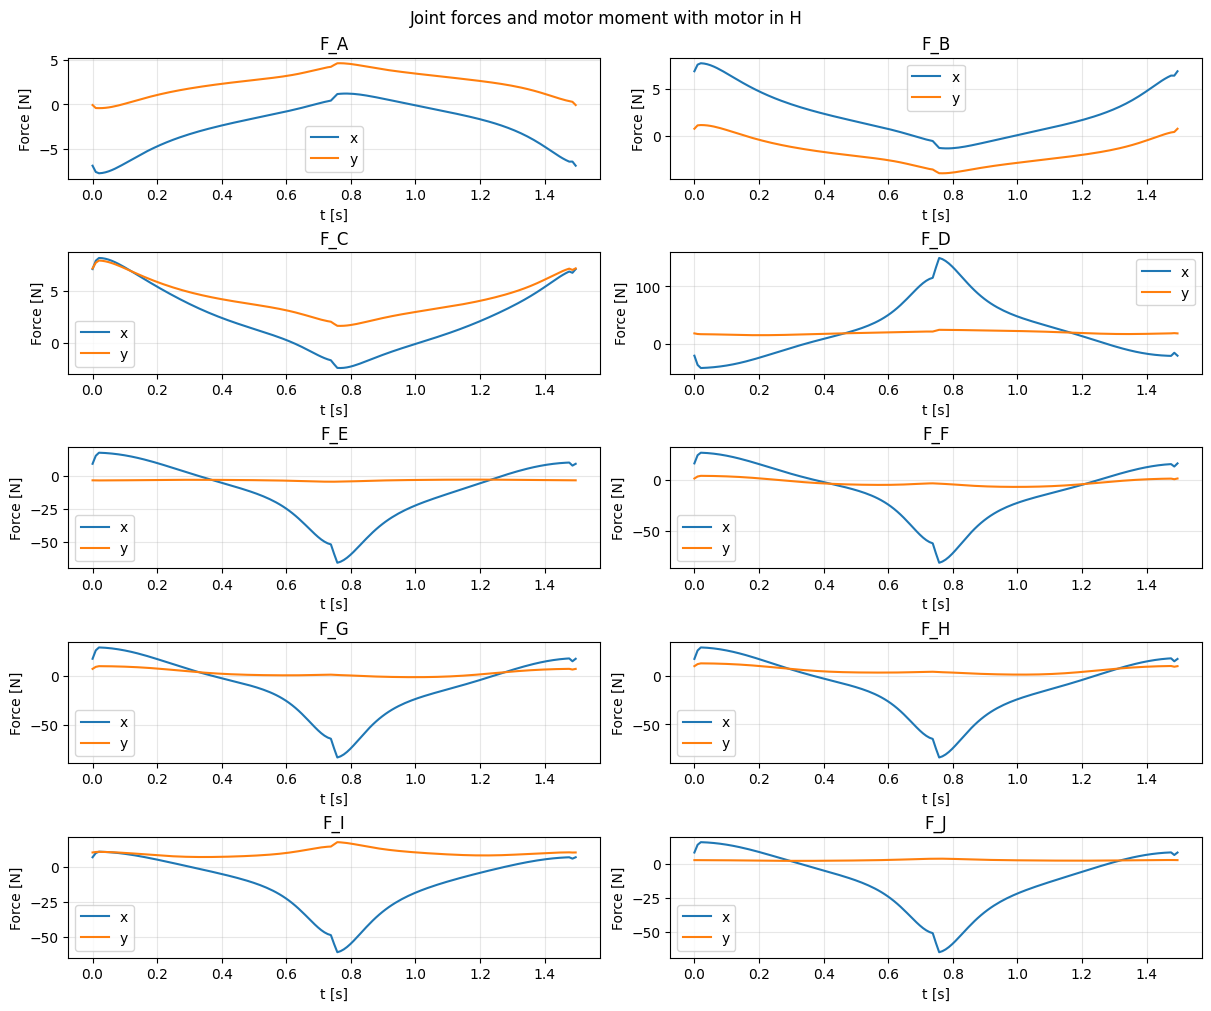

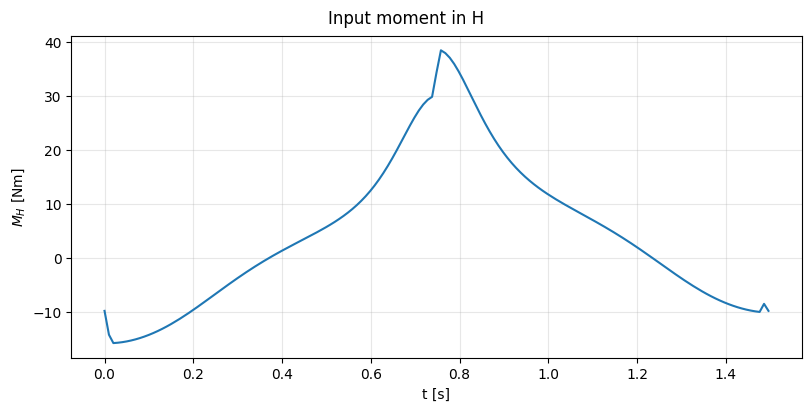

In [60]:
# plot forces and motor moment:
fig3, ax3 = plt.subplots(nrows=5, ncols=2, constrained_layout=True, figsize=(12, 10))
fig3.suptitle('Joint forces and motor moment with motor in H')

force_plots = [
    ('A', F_A_x, F_A_y), ('B', F_B_x, F_B_y),
    ('C', F_C_x, F_C_y), ('D', F_D_x, F_D_y),
    ('E', F_E_x, F_E_y), ('F', F_F_x, F_F_y),
    ('G', F_G_x, F_G_y), ('H', F_H_x, F_H_y),
    ('I', F_I_x, F_I_y), ('J', F_J_x, F_J_y),
]

for axis, (label, force_x, force_y) in zip(ax3.flat, force_plots):
    axis.plot(t, force_x, label='x')
    axis.plot(t, force_y, label='y')
    axis.set_title(f'F_{label}')
    axis.set_ylabel('Force [N]')
    axis.set_xlabel('t [s]')
    axis.grid(True)
    axis.legend()
plt.show()

fig4, ax4 = plt.subplots(constrained_layout=True, figsize=(8, 4))
fig4.suptitle('Input moment in H')
ax4.plot(t, M_H)
ax4.set_ylabel(r'$M_H$ [Nm]')
ax4.set_xlabel('t [s]')
ax4.grid(True)
plt.show()

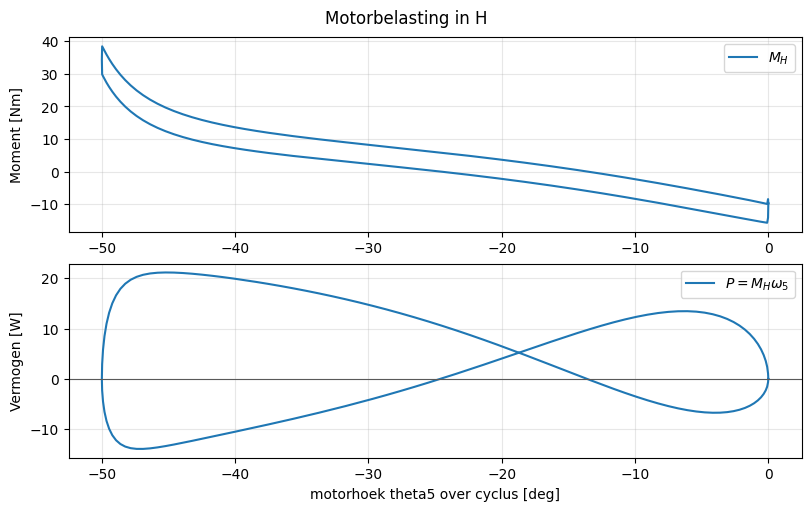

Motoranalyse in H
Piekmoment:             38.4 Nm
Continu/RMS-moment:     14.6 Nm
Piekvermogen:           21.1 W
Gemiddeld motorvermogen:6.62 W


In [61]:
fig_m, ax_m = plt.subplots(nrows=2, ncols=1, constrained_layout=True, figsize=(8, 5))
fig_m.suptitle('Motorbelasting in H')
ax_m[0].plot(theta5_cycle_deg, M_H, label=r'$M_H$')
ax_m[0].set_ylabel('Moment [Nm]')
ax_m[0].legend()
P_motor = M_H*dtheta5
P_motoring = np.maximum(P_motor, 0)
ax_m[1].plot(theta5_cycle_deg, P_motor, label=r'$P=M_H\omega_5$')
ax_m[1].axhline(0, color='0.35', linewidth=0.8)
ax_m[1].set_ylabel('Vermogen [W]')
ax_m[1].set_xlabel('motorhoek theta5 over cyclus [deg]')
ax_m[1].legend()
plt.show()

M_motor_peak = np.max(np.abs(M_H))
M_motor_rms = np.sqrt(cycle_average(M_H**2))
P_motor_peak = np.max(P_motoring)
P_motor_average_motoring = cycle_average(P_motoring)
print('Motoranalyse in H')
print(f'Piekmoment:             {M_motor_peak:.3g} Nm')
print(f'Continu/RMS-moment:     {M_motor_rms:.3g} Nm')
print(f'Piekvermogen:           {P_motor_peak:.3g} W')
print(f'Gemiddeld motorvermogen:{P_motor_average_motoring:.3g} W')

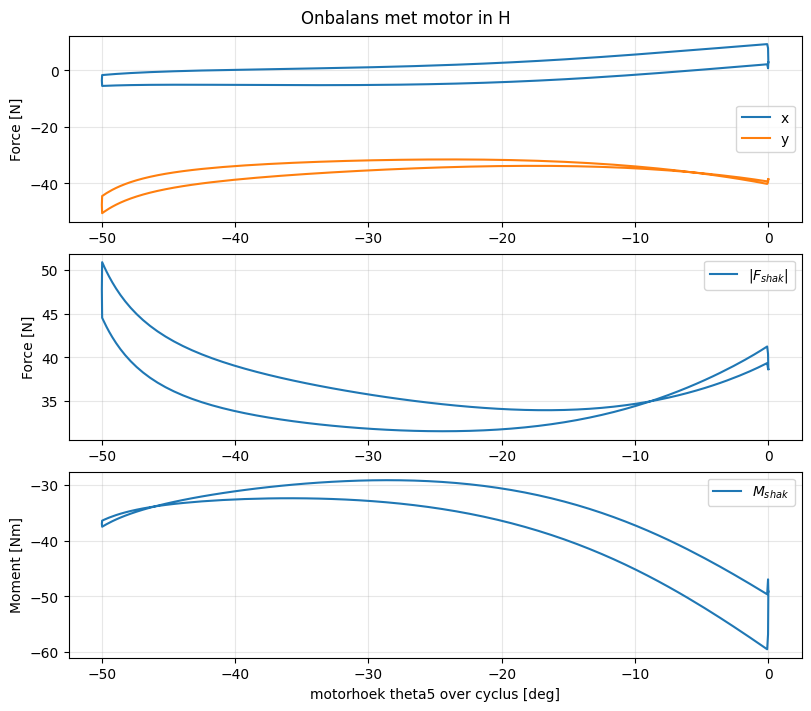

Peak |F_shak|:   50.9 N
Peak |M_shak|:   59.5 Nm


In [62]:
F_shak_x = -(F_A_x + F_D_x + F_H_x + F_I_x)
F_shak_y = -(F_A_y + F_D_y + F_H_y + F_I_y)
F_shak = np.hypot(F_shak_x, F_shak_y)
M_shak = -(
    grondA_x*F_A_y - grondA_y*F_A_x +
    grondD_x*F_D_y - grondD_y*F_D_x +
    grondH_x*F_H_y - grondH_y*F_H_x +
    grondI_x*F_I_y - grondI_y*F_I_x +
    M_H
)
fig_s, ax_s = plt.subplots(nrows=3, ncols=1, constrained_layout=True, figsize=(8, 7))
fig_s.suptitle('Onbalans met motor in H')
ax_s[0].plot(theta5_cycle_deg, F_shak_x, label='x')
ax_s[0].plot(theta5_cycle_deg, F_shak_y, label='y')
ax_s[0].set_ylabel('Force [N]'); ax_s[0].legend()
ax_s[1].plot(theta5_cycle_deg, F_shak, label=r'$|F_{shak}|$')
ax_s[1].set_ylabel('Force [N]'); ax_s[1].legend()
ax_s[2].plot(theta5_cycle_deg, M_shak, label=r'$M_{shak}$')
ax_s[2].set_ylabel('Moment [Nm]'); ax_s[2].set_xlabel('motorhoek theta5 over cyclus [deg]'); ax_s[2].legend()
plt.show()
print(f'Peak |F_shak|:   {np.max(F_shak):.3g} N')
print(f'Peak |M_shak|:   {np.max(np.abs(M_shak)):.3g} Nm')

## Besluit

De motor zit nu in `H`: `theta5` wordt rechtstreeks opgelegd als rockerbeweging. De lengtes liggen opnieuw dicht bij het oorspronkelijke ontwerp (`r2 = 0.99 m`, `r6 = 0.90 m`, `r7 = 0.50 m`). Daardoor is deze versie mechanisch veel realistischer dan de vorige H-crankvariant met een zeer korte `r7`.

De motor draait hier niet 360 graden, maar oscilleert ongeveer tussen `64 deg` en `114 deg`. Dat is iets kleiner dan de oorspronkelijke beweging, maar het vermijdt de ongunstigste eindstanden. Met de volledige oude range werd het gevraagde H-moment veel te groot.

De notebook bevat opnieuw de kinematicaplots, conditiegetalplot, animatie, inverse-dynamica-krachten, onbalansplots en motoranalyse. De sanity-check geeft voor deze variant: maximaal conditiegetal ongeveer `21`, piekmoment in H ongeveer `38 Nm`, piek-onbalanskracht ongeveer `51 N` en piek-onbalansmoment ongeveer `60 Nm`.

Voor een echte motoroplossing betekent dit dat je ofwel een motor met een omkeerbare/servo-achtige sturing nodig hebt, ofwel een extra kruk-reductiemechanisme dat een volledige motorrotatie omzet naar deze rockerbeweging in H. Deze versie is dus realistischer qua stanglengtes, maar minder eenvoudig qua aandrijving dan een gewone continu draaiende crank.